<a href="https://colab.research.google.com/github/irenehavsa/mental-disorder-prevalence/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Project: Analysis of the Depression Trend Over Time in Indonesia
# Notebook: 01_eda.ipynb
# Author: Irene Havsa

In [ ]:
# Install required packages
!pip install -r requirement.txt

In [ ]:
# Upload API Key file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"irenehavsa","key":"7ea0ccf77d2c8fa6cf35cd33c05d43c1"}'}

In [ ]:
# Move API Key file to the correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Import required packages
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

### 1. Import Data

The dataset used in this notebook is sourced from Kaggle. See here for more details: https://www.kaggle.com/datasets/thedevastator/uncover-global-trends-in-mental-health-disorder/data.

In [ ]:
# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("thedevastator/uncover-global-trends-in-mental-health-disorder")

print("Path to dataset files:", path)

# List contents of the downloaded path to identify the CSV file
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

Using Colab cache for faster access to the 'uncover-global-trends-in-mental-health-disorder' dataset.
Path to dataset files: /kaggle/input/uncover-global-trends-in-mental-health-disorder
Files in dataset directory: ['Mental health Depression disorder Data.csv']


In [ ]:
# Read the CSV
file_path = os.path.join(path, "Mental health Depression disorder Data.csv")
df = pd.read_csv(file_path) #to do: remove the index column
display(df.head())

/tmp/ipython-input-1756630372.py:3: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path) #to do: remove the index column


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260


###Explore Original Data

In [ ]:
# See the number of rows and columns
df.shape

In [ ]:
# See list of columns and their data type
df.info()

# Note of result-1: the columns' naming convention are not standard. I'll modify them into snake_case and remove unnecessary symbols and words.
# Note of result-2: the original index column is not needed for analysis, thus should be removed.

In [ ]:
# See list of countries
df.Entity.unique()

# Note of result-1: There is an entity "World", which is the prevalance data of the whole countries combined. There is also "Southeast Asia", which should represent the prevalance of all SEA countries combined.
# Note of result-2: Timor separated from Indonesia in May 2002, therefore if there is prevalence data before that year, it is unreliable. Note that this data is synthethic and there could be parts that don't make sense.

In [ ]:
# See list of years
df.Year.unique()

# Note of result: there is data of the BCE years, which shouldn't be possible. I'll explore the data on the next step.

In [ ]:
# Explore data of various years and value of columns

# df.loc[(df['Year'] == '1000 BCE')]
# df.loc[(df['Year'] == '1990')]
# df.loc[(df['Depression (%)'].notnull())]
df.loc[(df['Year'] == '1990') & (df['Depression (%)'].notnull())]

# Note of result: only data with the year 1990 and later AND depression data not null is valid, therefore the other should be removed.

In [ ]:
# See sample of complete data of a country
df.loc[(df['Entity'] == 'Timor') & (df['Depression (%)'].notnull())]

# Note of result: here it shows that there is data for Timor for the years before 2002. They are not valid since at those time Timor was still part of Indonesia. Thus, the data will be removed.

###2. Cleanse and Prepare Data

From the original data exploration above, here is what I'll do:
1.   Remove 'index' column
2.   Rename columns' name into snake_case and remove unnecessary symbols and words to make them compact
3.   Since the scope of the analysis is Southeast Asia (SEA), only include data with Entity includes SEA countries, "Southeast Asia", and "World"
4.   Only include data with the year 1990 or later and with 'depression' column not null.
5.   Exclude data of East Timor ("Timor") before the year 2002, since it is not valid   



In [ ]:
# Create a copy of the original dataframe
df_original = df.copy()

In [ ]:
# df = df_original.copy()

# Remove the original index column since it will not be used in this analysis
df = df.drop(columns=['index'])

# Rename columns' name
df.columns = ['entity', 'code', 'year', 'schizophrenia', 'bipolar', 'eating_disorder', 'anxiety', 'drug_use', 'depression', 'alcohol_use']

# Convert prevalence columns to numeric, coercing errors to NaN
prevalence_columns = ['schizophrenia', 'bipolar', 'eating_disorder', 'anxiety', 'drug_use', 'depression', 'alcohol_use']
for col in prevalence_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Include only relevant entities
entities_to_include = ['Southeast Asia', 'World', 'Indonesia', 'Timor', 'Malaysia', 'Singapore', 'Brunei', 'Philippines', 'Myanmar', 'Thailand', 'Laos', 'Cambodia']
df = df[df['entity'].isin(entities_to_include)]

# Include only valid data: year >= 1990 and 'depression' is not null
# First change the 'year' data type into numeric
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df[(df['year'] >= 1990) & (df['depression'].notnull())]

# Apply country-specific minimum year thresholds
df = df[(df['entity'] != 'Timor') | (df['year'] >= 2002)]

# Display the updated dataframe
display(df.head())

,entity,code,year,schizophrenia,bipolar,eating_disorder,anxiety,drug_use,depression,alcohol_use
784,Brunei,BRN,1990.0,0.274544,0.617719,0.550731,3.548453,0.911231,2.577977,0.771017
785,Brunei,BRN,1991.0,0.273819,0.618347,0.548010,3.554565,0.910156,2.562828,0.770862
786,Brunei,BRN,1992.0,0.273212,0.618986,0.545544,3.561621,0.910287,2.551382,0.770430
787,Brunei,BRN,1993.0,0.272736,0.619673,0.543644,3.569155,0.910409,2.543804,0.769584
788,Brunei,BRN,1994.0,0.272383,0.620342,0.542626,3.576319,0.908915,2.538465,0.768343


In [ ]:
# Review updated dataframe
# df.loc[(df['entity'] == 'Southeast Asia')]
df.loc[(df['entity'] == 'Thailand')]

,entity,code,year,schizophrenia,bipolar,eating_disorder,anxiety,drug_use,depression,alcohol_use
5712,Thailand,THA,1990.0,0.214772,0.529949,0.121902,3.248571,0.751753,2.979739,0.816724
5713,Thailand,THA,1991.0,0.215890,0.530608,0.124876,3.250578,0.753249,2.994226,0.830684
5714,Thailand,THA,1992.0,0.217011,0.531299,0.128137,3.253267,0.757215,3.005804,0.844540
5715,Thailand,THA,1993.0,0.218082,0.531985,0.130918,3.256435,0.762431,3.019329,0.858151
5716,Thailand,THA,1994.0,0.219050,0.532633,0.133336,3.259934,0.768406,3.033093,0.871374
5717,Thailand,THA,1995.0,0.219850,0.533173,0.135625,3.263349,0.773351,3.043687,0.884023
5718,Thailand,THA,1996.0,0.220704,0.533727,0.137774,3.267825,0.790750,3.052955,0.898256
5719,Thailand,THA,1997.0,0.221770,0.534417,0.139434,3.273845,0.822350,3.064761,0.914241
5720,Thailand,THA,1998.0,0.222879,0.535165,0.141336,3.280344,0.857609,3.073758,0.928917
5721,Thailand,THA,1999.0,0.223869,0.535922,0.142587,3.286557,0.887794,3.082819,0.939163


###3. Mental Disorders Trend Over Time

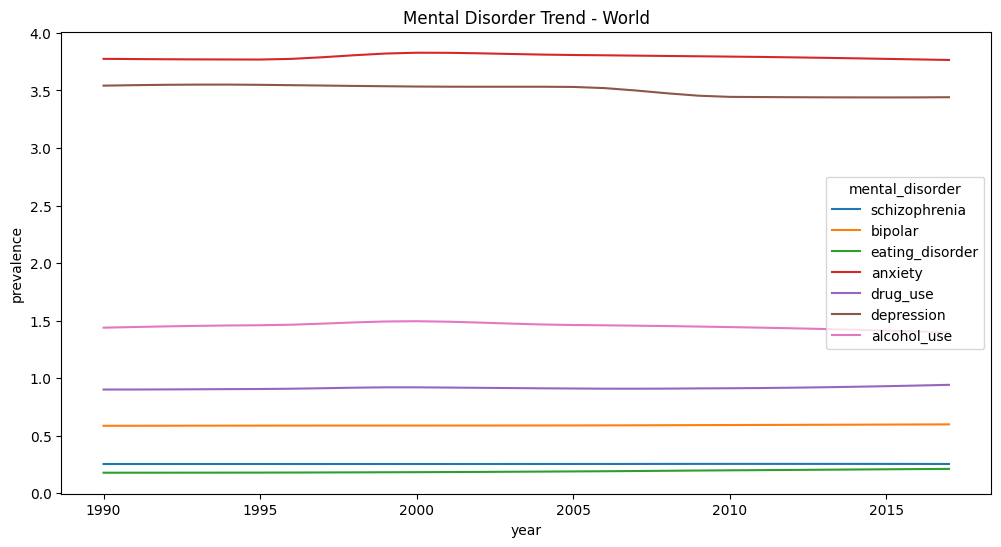

In [ ]:
df_all_prevalence_world = df_all_prevalence[df_all_prevalence['entity'].isin(['World'])]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all_prevalence_world, x='year', y='prevalence', hue='mental_disorder')
plt.title('Mental Disorders Trend Over Time - World')
plt.show()

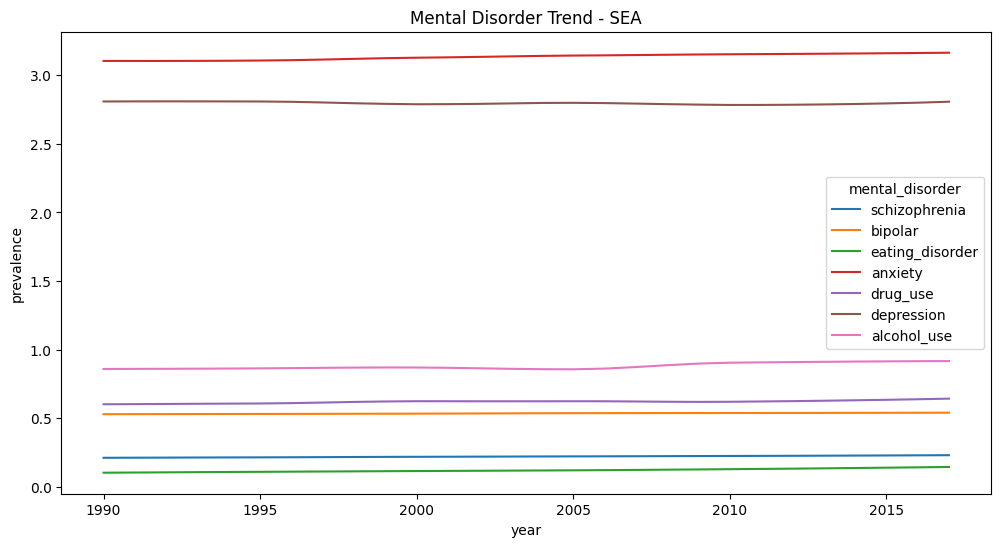

In [ ]:
df_all_prevalence_sea = df_all_prevalence[df_all_prevalence['entity'].isin(['Southeast Asia'])]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all_prevalence_sea, x='year', y='prevalence', hue='mental_disorder')
plt.title('Mental Disorders Trend Over Time - SEA')
plt.show()

###2. Depression Trend Over Time



In [ ]:
# There should be 11*28 + 1*16 (for Timor) = 324 rows
df.shape


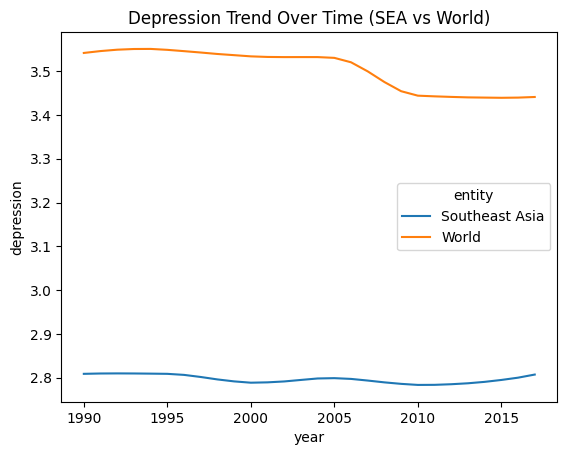

In [ ]:
# Depression Trend
df_global = df[df['entity'].isin(['Southeast Asia', 'World'])]

sns.lineplot(data=df_global, x='year', y='depression', hue='entity')
plt.title('Depression Trend Over Time (SEA vs World)')
plt.show()


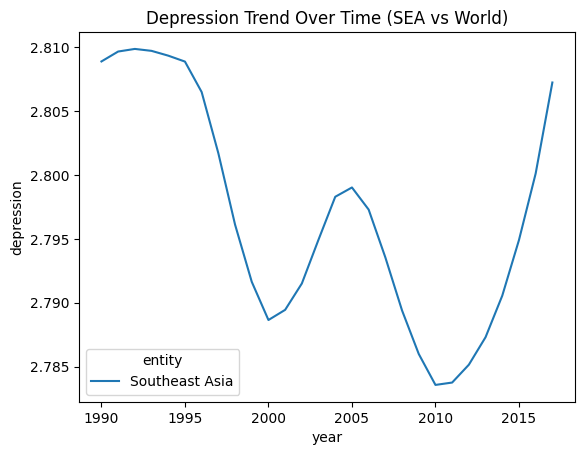

In [ ]:
# Depression Trend
df_global = df[df['entity'].isin(['Southeast Asia'])]

sns.lineplot(data=df_global, x='year', y='depression', hue='entity')
plt.title('Depression Trend Over Time (SEA')
plt.show()


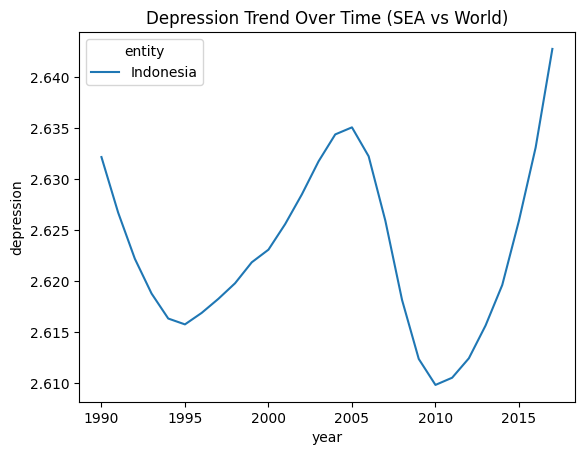

In [ ]:
# Depression Trend
df_global = df[df['entity'].isin(['Indonesia'])]

sns.lineplot(data=df_global, x='year', y='depression', hue='entity')
plt.title('Depression Trend Over Time (SEA vs World)')
plt.show()


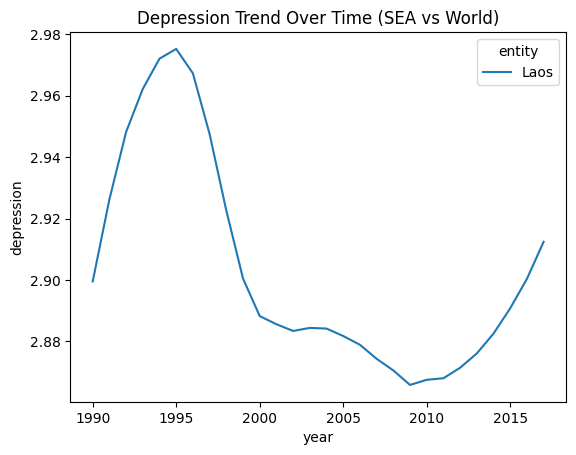

In [ ]:
# Depression Trend
df_global = df[df['entity'].isin(['Laos'])]

sns.lineplot(data=df_global, x='year', y='depression', hue='entity')
plt.title('Depression Trend Over Time (SEA vs World)')
plt.show()


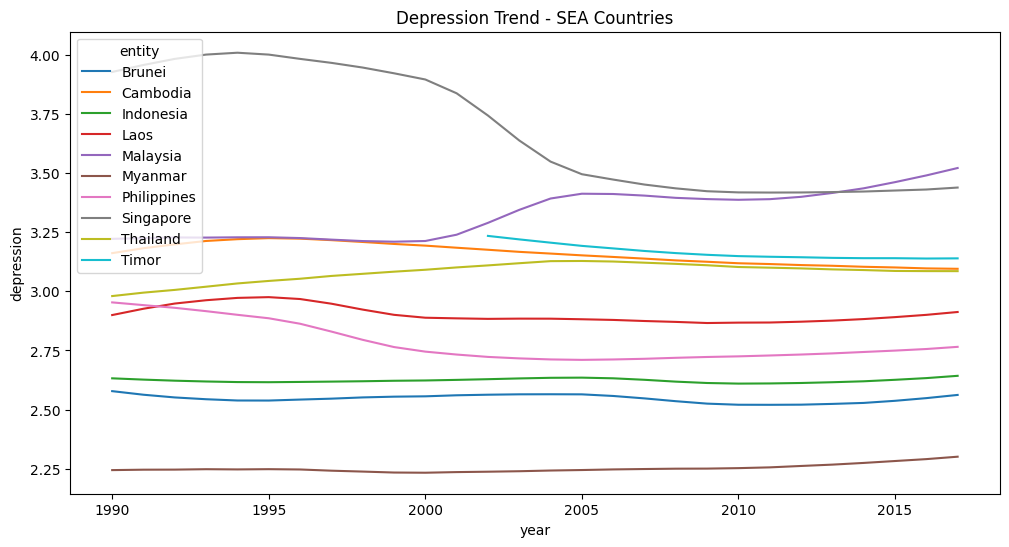

In [ ]:
countries = ['Indonesia', 'Malaysia', 'Singapore', 'Brunei', 'Philippines', 'Myanmar', 'Thailand', 'Laos', 'Cambodia', 'Timor']
df_countries = df[df['entity'].isin(countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_countries, x='year', y='depression', hue='entity')
plt.title('Depression Trend - SEA Countries')
plt.show()

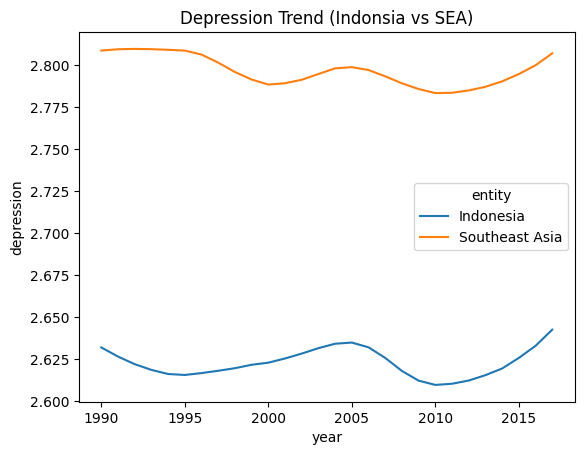

In [ ]:
# Depression Trend
df_indonesia_sea = df[df['entity'].isin(['Indonesia', 'Southeast Asia'])]

sns.lineplot(data=df_indonesia_sea, x='year', y='depression', hue='entity')
plt.title('Depression Trend (Indonsia vs SEA)')
plt.show()


In [ ]:
df_singapore_sea = df[df['entity'].isin(['Singapore', 'Southeast Asia'])]

sns.lineplot(data=df_singapore_sea, x='year', y='depression', hue='entity')
plt.title('Depression Trend (Singapore vs SEA)')
plt.show()


In [ ]:
# 'Unpivot' prevalence data
df_all_prevalence = pd.melt(df, id_vars=['entity', 'code', 'year'], var_name='mental_disorder', value_name='prevalence')
df_all_prevalence.head()

,entity,code,year,mental_disorder,prevalence
0,Brunei,BRN,1990.0,schizophrenia,0.274544
1,Brunei,BRN,1991.0,schizophrenia,0.273819
2,Brunei,BRN,1992.0,schizophrenia,0.273212
3,Brunei,BRN,1993.0,schizophrenia,0.272736
4,Brunei,BRN,1994.0,schizophrenia,0.272383


###Anxiety Trend Over Time

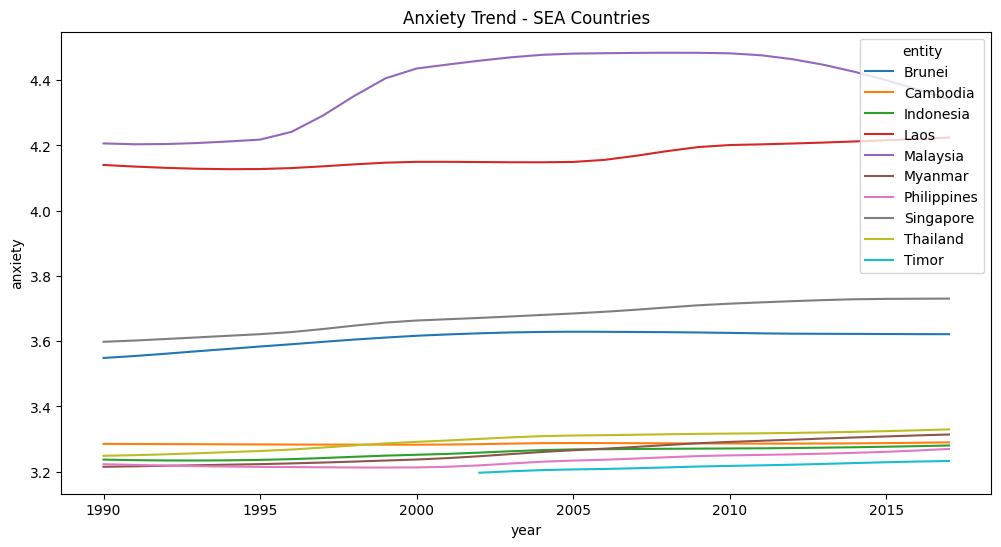

In [ ]:
countries = ['Indonesia', 'Malaysia', 'Singapore', 'Brunei', 'Philippines', 'Myanmar', 'Thailand', 'Laos', 'Cambodia', 'Timor']
df_countries = df[df['entity'].isin(countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_countries, x='year', y='anxiety', hue='entity')
plt.title('Anxiety Trend - SEA Countries')
plt.show()

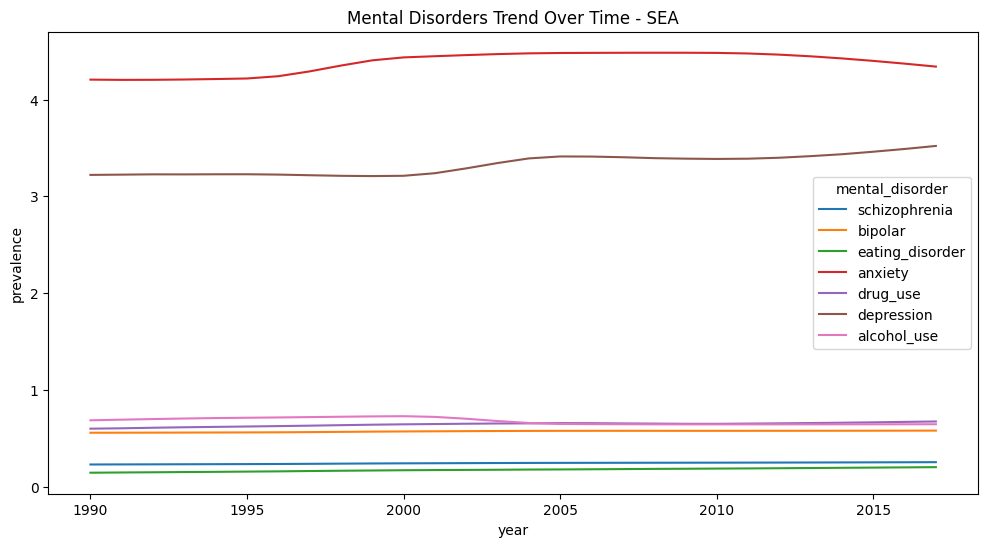

In [ ]:
df_all_prevalence_sea = df_all_prevalence[df_all_prevalence['entity'].isin(['Malaysia'])]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all_prevalence_sea, x='year', y='prevalence', hue='mental_disorder')
plt.title('Mental Disorders Trend Over Time - Malaysia')
plt.show()

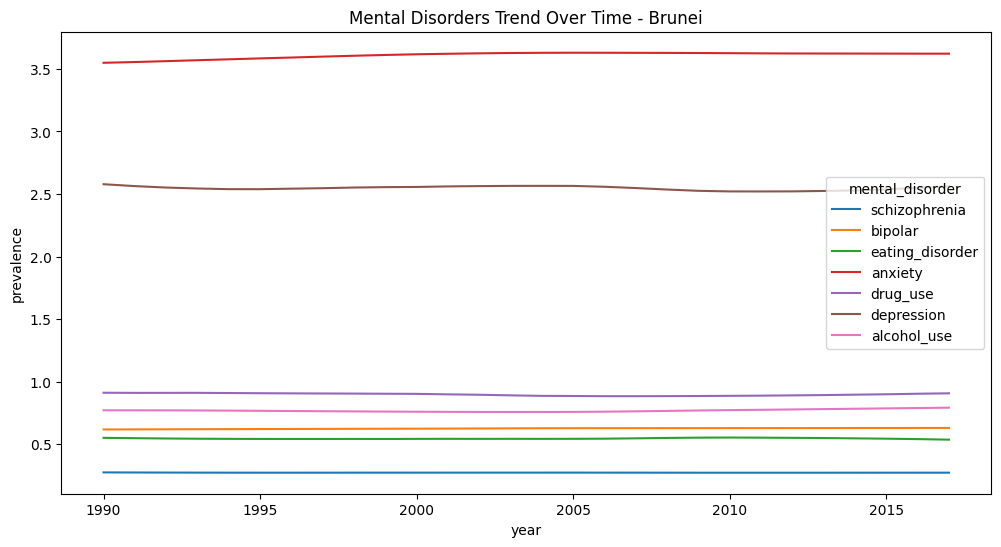

In [ ]:
df_all_prevalence_sea = df_all_prevalence[df_all_prevalence['entity'].isin(['Thailand'])]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all_prevalence_sea, x='year', y='prevalence', hue='mental_disorder')
plt.title('Mental Disorders Trend Over Time - Thailand')
plt.show()